# UPI Payment Transactions – Fraud & Spending Analysis (Python / Pandas)

A UPI transactions analytics project covering data cleaning, table merging,
and business-question-driven fraud analysis.

**Dataset:** 20,000 UPI transactions across 2,000 users and 400 merchants (Jan–Dec 2024)
**Tools:** Python, Pandas, Matplotlib


## Section 1: Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\gurra\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load all dataset files
transactions = pd.read_csv("C:/Users/gurra/Downloads/UPI Payment Transactions India/transactions.csv")
users = pd.read_csv("C:/Users/gurra/Downloads/UPI Payment Transactions India/users.csv")
merchants = pd.read_csv("C:/Users/gurra/Downloads/UPI Payment Transactions India/merchants.csv")
fraud_labels = pd.read_csv("C:/Users/gurra/Downloads/UPI Payment Transactions India/fraud_labels.csv")
data_dictionary = pd.read_csv("C:/Users/gurra/Downloads/UPI Payment Transactions India/data_dictionary.csv")

In [3]:
# Quick look at each file
transactions.head()

,transaction_id,user_id,receiver_id,receiver_type,amount,timestamp,date,hour_of_day,day_of_week,is_weekend,...,user_loyalty_score,new_device_flag,ip_location_mismatch,failed_attempts_last_24h,transaction_velocity,amount_deviation_score,is_fraud,recurring_payment_flag,balance_after_transaction,transaction_frequency_score
0,TXN0013171,USR01949,MRC0069,Merchant,1533.88,2024-01-01 00:21:17,2024-01-01,0,Monday,0,...,0.194,0,0,2,0.0,2.2467,0,1,36023.96,0.72
1,TXN0006480,USR01975,MRC0048,Merchant,1371.57,2024-01-01 00:36:29,2024-01-01,0,Monday,0,...,0.213,0,0,0,4.0,1.1773,0,0,65138.89,0.68
2,TXN0001430,USR01127,MRC0312,Merchant,500.50,2024-01-01 00:47:46,2024-01-01,0,Monday,0,...,0.381,0,0,0,1.0,0.1471,0,1,69347.11,0.86
3,TXN0003501,USR00827,USR01877,User,724.05,2024-01-01 00:52:07,2024-01-01,0,Monday,0,...,0.238,0,0,1,0.0,1.6019,0,0,52305.43,1.00
4,TXN0004423,USR00673,USR00534,User,128.22,2024-01-01 01:22:31,2024-01-01,1,Monday,0,...,0.187,0,0,5,1.0,0.3076,0,0,9601.13,0.48


In [4]:
users.head()

,user_id,age_group,city,city_tier,kyc_status,account_age_days,linked_bank_count,avg_monthly_transactions,avg_transaction_value,preferred_app,preferred_device,user_loyalty_score,is_high_risk_user
0,USR00001,55+,Surat,Tier 2,Verified,486,1,19,629.65,GPay,Android,0.348,0
1,USR00002,35-44,Tiruchirappalli,Tier 3,Verified,449,2,15,429.28,GPay,Android,0.903,0
2,USR00003,25-34,Pune,Tier 1,Verified,160,1,56,340.67,GPay,Android,0.297,0
3,USR00004,25-34,Jaipur,Tier 2,Verified,2328,1,30,221.18,PhonePe,Android,0.685,0
4,USR00005,18-24,Nagpur,Tier 2,Verified,1869,2,24,918.09,GPay,iOS,0.828,1


In [5]:
merchants.head()

,merchant_id,merchant_name,merchant_category,merchant_size,city,city_tier,avg_daily_transactions,is_registered,rating
0,MRC0001,Merchant_1,Insurance,Medium,Bhopal,Tier 2,60,1,4.2
1,MRC0002,Merchant_2,Travel,Small,Coimbatore,Tier 2,7,1,4.7
2,MRC0003,Merchant_3,Utilities,Small,Mumbai,Tier 1,4,1,4.1
3,MRC0004,Merchant_4,Grocery,Small,Rajkot,Tier 2,16,1,4.2
4,MRC0005,Merchant_5,Travel,Small,Mumbai,Tier 1,10,1,2.8


In [6]:
fraud_labels.head()

,transaction_id,user_id,receiver_id,amount,timestamp,is_fraud,new_device_flag,ip_location_mismatch,failed_attempts_last_24h,transaction_velocity,amount_deviation_score
0,TXN0000001,USR01603,MRC0374,1650.84,2024-12-26 14:52:00,0,0,0,0,0.0,0.5146
1,TXN0000002,USR01759,MRC0274,599.20,2024-06-29 00:09:24,0,0,0,1,0.0,0.7026
2,TXN0000003,USR01894,MRC0122,261.36,2024-02-21 05:08:33,0,0,0,0,0.0,0.1547
3,TXN0000004,USR00606,USR00692,215.71,2024-08-09 18:52:33,0,0,0,0,0.0,0.0078
4,TXN0000005,USR01246,MRC0007,411.15,2024-02-18 06:37:11,0,0,0,1,1.0,0.1170


## Section 2: Data Quality Checks

Before cleaning or analyzing anything, each file was checked for missing values,
duplicate rows, and (where relevant) ID uniqueness — since these tables will
later be merged together on their ID columns.


In [7]:
# --- transactions.csv ---
transactions.isnull().sum()

transaction_id                    0
user_id                           0
receiver_id                       0
receiver_type                     0
amount                            0
timestamp                         0
date                              0
hour_of_day                       0
day_of_week                       0
is_weekend                        0
is_night_transaction              0
time_since_last_txn_min        2335
transaction_type                  0
payment_app                       0
device_type                       0
status                            0
user_city_tier                    0
user_kyc_status                   0
user_avg_monthly_txn              0
user_avg_txn_value                0
user_loyalty_score                0
new_device_flag                   0
ip_location_mismatch              0
failed_attempts_last_24h          0
transaction_velocity            393
amount_deviation_score          367
is_fraud                          0
recurring_payment_flag      

In [8]:
transactions.duplicated().sum()

0

In [9]:
transactions.describe()

,amount,hour_of_day,is_weekend,is_night_transaction,time_since_last_txn_min,user_avg_monthly_txn,user_avg_txn_value,user_loyalty_score,new_device_flag,ip_location_mismatch,failed_attempts_last_24h,transaction_velocity,amount_deviation_score,is_fraud,recurring_payment_flag,balance_after_transaction,transaction_frequency_score
count,20000.000000,20000.000000,20000.000000,20000.000000,17665.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,19607.000000,19633.000000,20000.000000,20000.00000,20000.000000,20000.000000
mean,876.846854,11.565050,0.281400,0.324600,-899.133724,31.939000,691.624428,0.56031,0.064800,0.038450,0.537250,0.547101,0.653635,0.038150,0.30210,40413.740081,0.615067
std,1083.900556,6.867629,0.449693,0.468237,214733.190266,14.645696,517.225583,0.25846,0.246179,0.192285,1.040705,0.999292,0.789019,0.191563,0.45918,22915.172130,0.246966
min,13.700000,0.000000,0.000000,0.000000,-517802.170000,1.000000,52.280000,0.10100,0.000000,0.000000,0.000000,0.000000,0.000100,0.000000,0.00000,500.750000,0.020000
25%,277.672500,6.000000,0.000000,0.000000,-154683.080000,21.000000,332.470000,0.33000,0.000000,0.000000,0.000000,0.000000,0.221500,0.000000,0.00000,20328.310000,0.420000
50%,539.955000,12.000000,0.000000,0.000000,-1724.130000,30.000000,544.550000,0.56900,0.000000,0.000000,0.000000,0.000000,0.444500,0.000000,0.00000,40398.730000,0.600000
75%,1061.510000,17.000000,1.000000,1.000000,153152.770000,40.000000,904.770000,0.78000,0.000000,0.000000,1.000000,1.000000,0.727600,0.000000,1.00000,60474.840000,0.800000
max,32259.720000,23.000000,1.000000,1.000000,524477.870000,84.000000,4539.450000,1.00000,1.000000,1.000000,5.000000,4.000000,11.359200,1.000000,1.00000,79997.750000,1.000000


In [10]:
transactions['is_fraud'].value_counts()
# 763 of 20,000 transactions (3.8%) are fraud — matches the dataset's documented fraud rate.

is_fraud
0    19237
1      763
Name: count, dtype: int64

In [11]:
# --- users.csv ---
users.isnull().sum()

user_id                     0
age_group                   0
city                        0
city_tier                   0
kyc_status                  0
account_age_days            0
linked_bank_count           0
avg_monthly_transactions    0
avg_transaction_value       0
preferred_app               0
preferred_device            0
user_loyalty_score          0
is_high_risk_user           0
dtype: int64

In [12]:
users.duplicated().sum()

0

In [13]:
users['user_id'].is_unique
# True — safe to use as a merge key.

True

In [14]:
users.describe()

,account_age_days,linked_bank_count,avg_monthly_transactions,avg_transaction_value,user_loyalty_score,is_high_risk_user
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1290.886000,1.736000,31.931500,694.935835,0.558273,0.053500
std,698.671814,0.876749,14.678813,521.760957,0.259702,0.225085
min,30.000000,1.000000,1.000000,52.280000,0.101000,0.000000
25%,679.500000,1.000000,21.000000,332.172500,0.329000,0.000000
50%,1304.500000,2.000000,30.000000,545.035000,0.563000,0.000000
75%,1892.000000,2.000000,40.000000,908.277500,0.781000,0.000000
max,2499.000000,4.000000,84.000000,4539.450000,1.000000,1.000000


In [15]:
# --- merchants.csv ---
merchants.isnull().sum()

merchant_id               0
merchant_name             0
merchant_category         0
merchant_size             0
city                      0
city_tier                 0
avg_daily_transactions    0
is_registered             0
rating                    0
dtype: int64

In [16]:
merchants.duplicated().sum()

0

In [17]:
merchants['merchant_id'].is_unique
# True — safe to use as a merge key.

True

In [18]:
merchants.describe()

,avg_daily_transactions,is_registered,rating
count,400.000000,400.000000,400.000000
mean,59.242500,0.927500,3.750250
std,82.287586,0.259639,0.723574
min,3.000000,0.000000,2.500000
25%,11.000000,1.000000,3.100000
50%,15.000000,1.000000,3.700000
75%,65.250000,1.000000,4.400000
max,425.000000,1.000000,5.000000


In [19]:
# --- fraud_labels.csv ---
fraud_labels.isnull().sum()

transaction_id                0
user_id                       0
receiver_id                   0
amount                        0
timestamp                     0
is_fraud                      0
new_device_flag               0
ip_location_mismatch          0
failed_attempts_last_24h      0
transaction_velocity        393
amount_deviation_score      367
dtype: int64

In [20]:
fraud_labels.duplicated().sum()

0

In [21]:
fraud_labels['is_fraud'].value_counts()
# Matches transactions.csv exactly (763 fraud / 3.8%) — fraud_labels.csv duplicates columns
# already present in transactions.csv, so it was not merged separately; transactions.csv
# was treated as the single source of truth for fraud-related fields.

is_fraud
0    19237
1      763
Name: count, dtype: int64

## Section 3: Data Cleaning

**Missing values:**
- `transaction_velocity` (393 missing, whole-number/count data) → filled with the **mode**
- `amount_deviation_score` (367 missing, continuous score) → filled with the **median**, since the
  mean was skewed upward by outliers (mean ≈ 0.65 vs median ≈ 0.44)
- `time_since_last_txn_min` (2,335 missing, plus ~8,900 logically invalid negative values) →
  **column dropped entirely**. Two hypotheses (a formula/direction bug, and a "first transaction
  has no prior gap" explanation) were tested against the data and neither matched the observed
  pattern — most users had several negative values, not just one — pointing to intentional
  synthetic noise rather than a fixable error.

**Date formatting:**
- `timestamp` converted from text to proper `datetime` type
- `date` column dropped as redundant, since it duplicated information already in `timestamp`


In [22]:
# Fill missing values
transactions["transaction_velocity"].fillna(transactions["transaction_velocity"].mode()[0], inplace=True)
transactions["amount_deviation_score"].fillna(transactions["amount_deviation_score"].median(), inplace=True)

C:\Users\gurra\AppData\Local\Temp\ipykernel_26504\3108765287.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transactions["transaction_velocity"].fillna(transactions["transaction_velocity"].mode()[0], inplace=True)
C:\Users\gurra\AppData\Local\Temp\ipykernel_26504\3108765287.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which

In [23]:
# Drop unreliable column (see note above)
transactions.drop("time_since_last_txn_min", axis=1, inplace=True)

In [24]:
# Fix date formatting
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])
transactions["date"] = pd.to_datetime(transactions["date"])
transactions.drop("date", axis=1, inplace=True)

In [25]:
# Verify cleaning
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   transaction_id               20000 non-null  object        
 1   user_id                      20000 non-null  object        
 2   receiver_id                  20000 non-null  object        
 3   receiver_type                20000 non-null  object        
 4   amount                       20000 non-null  float64       
 5   timestamp                    20000 non-null  datetime64[ns]
 6   hour_of_day                  20000 non-null  int64         
 7   day_of_week                  20000 non-null  object        
 8   is_weekend                   20000 non-null  int64         
 9   is_night_transaction         20000 non-null  int64         
 10  transaction_type             20000 non-null  object        
 11  payment_app                  20000 non-nu

## Section 4: Merging the Tables

`transactions` was merged with `users` (on `user_id`) and `merchants`
(on `receiver_id` ↔ `merchant_id`), both as **left joins**, since every
`user_id` and the relevant `receiver_id`s were already confirmed to have
valid matches. Merchant fields are intentionally `NaN` for P2P transactions,
since those genuinely have no merchant — left unfilled rather than guessed,
to avoid distorting later fraud analysis.

After merging, a few duplicate columns appeared (same information carried by
both `transactions.csv` and `users.csv`) and were cleaned up — each was checked
for identical values before deciding to drop or rename, rather than assumed:
- `user_loyalty_score_x` / `_y` → confirmed identical → kept one, renamed to `user_loyalty_score`
- `user_kyc_status` / `kyc_status` → confirmed identical → dropped the duplicate
- `city_tier_x` (transactions' version) → confirmed identical to `user_city_tier` → dropped
- `city_x` / `city_y` → confirmed genuinely different (user's city vs merchant's city) →
  renamed to `user_city` / `merchant_city`
- `city_tier_y` → renamed to `merchant_city_tier`


In [26]:
# Merge transactions with users (left join on user_id)
merged_data = pd.merge(transactions, users, on="user_id", how="left")
merged_data.shape

(20000, 40)

In [27]:
# Merge in merchants (left join on receiver_id / merchant_id)
merged_data = pd.merge(merged_data, merchants, left_on="receiver_id", right_on="merchant_id", how="left")
merged_data.shape

(20000, 49)

In [28]:
# Clean up duplicate/ambiguous columns created by the merge
merged_data.drop("city_tier_x", axis=1, inplace=True)
merged_data.rename(columns={
    "city_x": "user_city",
    "city_y": "merchant_city",
    "city_tier_y": "merchant_city_tier"
}, inplace=True)

merged_data.drop("user_loyalty_score_y", axis=1, inplace=True)
merged_data.rename(columns={"user_loyalty_score_x": "user_loyalty_score"}, inplace=True)

merged_data.drop("kyc_status", axis=1, inplace=True)

In [29]:
# Final verification — no data lost, no duplicate columns remaining
merged_data.shape

(20000, 46)

In [30]:
merged_data.columns

Index(['transaction_id', 'user_id', 'receiver_id', 'receiver_type', 'amount',
       'timestamp', 'hour_of_day', 'day_of_week', 'is_weekend',
       'is_night_transaction', 'transaction_type', 'payment_app',
       'device_type', 'status', 'user_city_tier', 'user_kyc_status',
       'user_avg_monthly_txn', 'user_avg_txn_value', 'user_loyalty_score',
       'new_device_flag', 'ip_location_mismatch', 'failed_attempts_last_24h',
       'transaction_velocity', 'amount_deviation_score', 'is_fraud',
       'recurring_payment_flag', 'balance_after_transaction',
       'transaction_frequency_score', 'age_group', 'user_city',
       'account_age_days', 'linked_bank_count', 'avg_monthly_transactions',
       'avg_transaction_value', 'preferred_app', 'preferred_device',
       'is_high_risk_user', 'merchant_id', 'merchant_name',
       'merchant_category', 'merchant_size', 'merchant_city',
       'merchant_city_tier', 'avg_daily_transactions', 'is_registered',
       'rating'],
      dtype='objec

## Section 5: Business Questions & Analysis

In [31]:
# Q1. Which merchant category has the highest fraud rate?
merged_data.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)

merchant_category
Fuel             0.055866
Insurance        0.046961
Grocery          0.046956
Food & Dining    0.043739
Healthcare       0.042601
Education        0.040248
Travel           0.036029
Utilities        0.034483
Recharge         0.031434
Shopping         0.030986
Entertainment    0.025751
Name: is_fraud, dtype: float64

In [32]:
# Supporting check: how many transactions does each category actually have?
# (fraud RATE alone can be misleading for small categories)
merged_data.groupby("merchant_category").size()

# Insight: Fuel shows the highest fraud rate (5.6%), followed by Insurance and Grocery (~4.7%).
# However, Fuel has only 179 transactions — the smallest category by far — making its fraud
# rate statistically unreliable, since a small sample can swing significantly from just a few
# random cases. Grocery has a very similar fraud rate (4.7%) but is backed by 2,513 transactions,
# making it a far more statistically trustworthy signal of genuine fraud risk.
#
# Recommendation: Prioritize fraud monitoring in the Grocery category, since its elevated fraud
# rate is supported by a large, reliable sample. Continue observing Fuel, but avoid major business
# decisions based on its current rate until more transaction data is collected.

merchant_category
Education         969
Entertainment    1165
Food & Dining    2835
Fuel              179
Grocery          2513
Healthcare        892
Insurance         362
Recharge         1527
Shopping         1775
Travel           1249
Utilities        1653
dtype: int64

In [33]:
# Q2. Which user city tier has the highest fraud rate?
merged_data.groupby("user_city_tier")["is_fraud"].mean().sort_values(ascending=False)

user_city_tier
Tier 3    0.040837
Tier 1    0.038821
Tier 2    0.035933
Name: is_fraud, dtype: float64

In [34]:
# Supporting check: transaction count per tier (to judge reliability of the fraud rate)
merged_data.groupby("user_city_tier").size()

# Insight: Tier 3 shows a higher fraud rate (4.08%) compared to Tier 2 (3.59%) and
# Tier 1 (3.88%). Unlike Q1's Fuel category, Tier 3 still has a decent sample size
# of 4,824 transactions, so this difference is unlikely to be random noise.
#
# Recommendation: The business should monitor Tier 3 transactions more closely,
# without shifting all fraud-prevention focus away from Tier 1 and Tier 2. A possible
# contributing factor is lower digital literacy in smaller cities, which could make
# users more vulnerable to fraud tactics — this should be investigated further,
# for example through user surveys or by reviewing common fraud patterns specific
# to Tier 3 transactions.

user_city_tier
Tier 1    7161
Tier 2    8015
Tier 3    4824
dtype: int64

In [35]:
# Q3. Does fraud occur more often during night transactions compared to day transactions?
merged_data.groupby("is_night_transaction")["is_fraud"].mean().sort_values(ascending=False)

is_night_transaction
1    0.052680
0    0.031167
Name: is_fraud, dtype: float64

In [36]:
# Supporting check: transaction count for night vs day (to judge reliability)
merged_data.groupby("is_night_transaction").size()

# Insight: Night transactions show a fraud rate of 5.27%, compared to 3.12% for day
# transactions — roughly 1.6x higher. With a solid sample size on both sides (6,492
# night vs 13,508 day transactions), this difference is unlikely to be random noise.
# This aligns with the intuitive expectation that fraud is more likely to occur at
# night, when users are less likely to be actively monitoring their accounts.
#
# Recommendation: Introduce additional verification steps (e.g. OTP or biometric
# confirmation) for transactions occurring during late-night hours, and enable
# real-time alert notifications for night-time transactions, so users can react
# quickly if a transaction wasn't authorized by them.

is_night_transaction
0    13508
1     6492
dtype: int64

In [37]:
# Q4. Does fraud occur more often on unrecognized (new) devices?
merged_data.groupby("new_device_flag")["is_fraud"].mean().sort_values(ascending=False)

new_device_flag
1    0.123457
0    0.032239
Name: is_fraud, dtype: float64

In [38]:
# Supporting check: transaction count for new vs familiar devices (to judge reliability)
merged_data.groupby("new_device_flag").size()

# Insight: Transactions from new/unrecognized devices show a fraud rate of 12.3%,
# compared to just 3.2% for familiar devices — roughly 3.8x higher, the largest gap
# found among all fraud-pattern questions in this analysis. With 1,296 new-device
# transactions (a reasonably solid sample on its own), this difference is unlikely
# to be random noise. This confirms that unfamiliar devices carry meaningfully
# higher fraud risk, likely because compromised accounts are often accessed from
# a device the legitimate user has never used.
#
# Recommendation: Since new/unrecognized devices represent the strongest fraud
# signal found in this analysis, transactions from new devices should trigger
# mandatory additional verification (e.g. PIN re-entry, OTP confirmation) before
# approval, along with an immediate high-priority alert to the user. New-device
# checks should be prioritized as a core fraud-prevention rule, given this is a
# stronger signal than transaction timing or merchant category.

new_device_flag
0    18704
1     1296
dtype: int64

In [39]:
# Q5. Which transaction type has the highest fraud rate?
merged_data.groupby("transaction_type")["is_fraud"].mean().sort_values(ascending=False)

transaction_type
P2M             0.039920
Subscription    0.039826
Recharge        0.037324
P2P             0.037287
Bill Payment    0.036927
EMI             0.035012
Name: is_fraud, dtype: float64

In [40]:
# Supporting check: transaction count per type (to judge reliability)
merged_data.groupby("transaction_type").size()

# Insight: Fraud rates across transaction types are surprisingly close together —
# ranging from 3.50% (EMI) to 3.99% (P2M), a much smaller spread than seen in other
# fraud signals like device type (12.3% vs 3.2%) or timing (5.27% vs 3.12%). Notably,
# this contradicts the initial hypothesis that P2P transfers would carry higher
# fraud risk than P2M (merchant) payments — the data shows P2P (3.73%) and P2M
# (3.99%) are nearly identical. This suggests transaction type alone is a weak
# predictor of fraud risk, unlike device familiarity or transaction timing.
#
# Recommendation: Since transaction type shows minimal variation in fraud risk, it
# should not be treated as a primary fraud-monitoring factor. Fraud-prevention
# resources should instead be concentrated on the strongest signals identified in
# this analysis — new/unrecognized devices (12.3% fraud rate) and night-time
# transactions (5.27% fraud rate) — rather than spread evenly across all
# transaction types.

transaction_type
Bill Payment    3033
EMI             1628
P2M             7014
P2P             4881
Recharge        2063
Subscription    1381
dtype: int64

In [41]:
# Q6. If a custom risk rule flags transactions that are both from a new device AND
# occur at night, how well does this rule actually align with real fraud outcomes?

merged_data["my_risk_flag"] = (merged_data["new_device_flag"] == 1) & (merged_data["is_night_transaction"] == 1)
merged_data["my_risk_flag"].value_counts()

my_risk_flag
False    19588
True       412
Name: count, dtype: int64

In [42]:
# Check how many flagged transactions were actually fraud
merged_data[merged_data["my_risk_flag"] == True]["is_fraud"].value_counts()

# Insight: A custom risk rule was built, flagging transactions as risky when they
# occurred on a new/unrecognized device AND during night-time hours — the two
# strongest individual fraud signals identified in this analysis. This rule flagged
# 412 transactions (2.1% of all transactions), of which 59 were confirmed fraud —
# a 14.3% fraud rate within the flagged group, nearly 4x higher than the overall
# dataset average of 3.8%. However, the rule only captured 59 of the 763 total
# fraud cases (7.7% coverage), confirming that most fraud occurs through other
# patterns not captured by these two conditions alone. This is a precision vs
# coverage trade-off: the rule is precise (highly likely to be right when it flags
# something) but has low coverage (misses most fraud overall).
#
# Recommendation: This rule should not be used as a standalone fraud detection
# system, since it only catches a small portion of overall fraud. Instead, it
# should be used as one component within a broader fraud-monitoring system —
# automatically flagging new-device-plus-night transactions for priority review,
# while additional rules are developed around other signals (transaction velocity,
# amount deviation, IP mismatches) to improve overall fraud coverage.

is_fraud
0    353
1     59
Name: count, dtype: int64

## Section 6: Visualizations

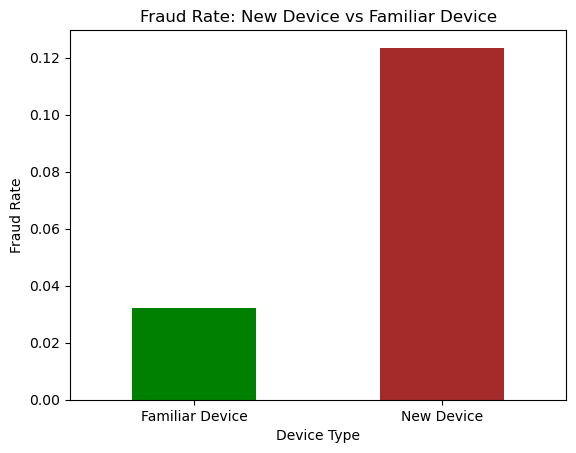

In [45]:
# Chart 1: Fraud rate by device familiarity
device_fraud = merged_data.groupby("new_device_flag")["is_fraud"].mean()

device_fraud.plot(kind="bar", color=["Green", "brown"])
plt.title("Fraud Rate: New Device vs Familiar Device")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate")
plt.xticks([0, 1], ["Familiar Device", "New Device"], rotation=0)
plt.show()

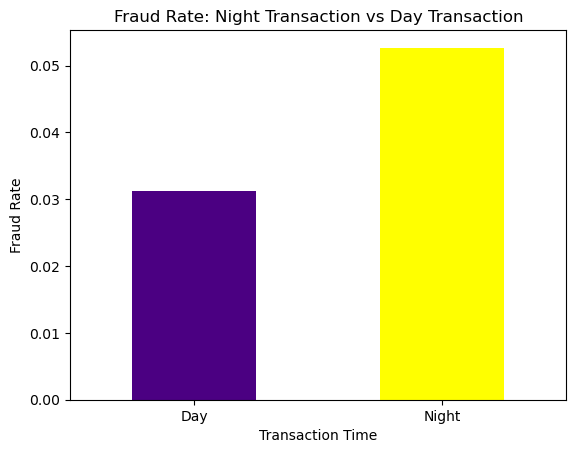

In [49]:
# Chart 2: Fraud rate by transaction timing
fraud_time = merged_data.groupby("is_night_transaction")["is_fraud"].mean()

fraud_time.plot(kind="bar", color=["Indigo", "yellow"])
plt.title("Fraud Rate: Night Transaction vs Day Transaction")
plt.xlabel("Transaction Time")
plt.ylabel("Fraud Rate")
plt.xticks([0, 1], ["Day", "Night"], rotation=0)
plt.show()